<a href="https://colab.research.google.com/github/Lawson-Dong/SINDy_code_reproduction/blob/main/Three_testing_system_for_SINDy_PI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SINDy-PI Noise Robustness Systematic Study
Based on Kaheman et al., 2020

Testing System: Constrained Falling Mass
  Testing noise level σ = 0.0100
  Testing noise level σ = 0.0200
  Testing noise level σ = 0.0500
  Testing noise level σ = 0.1000
  Testing noise level σ = 0.1500
  Testing noise level σ = 0.2000
  Testing noise level σ = 0.2500
  Testing noise level σ = 0.3000

Testing System: RC Circuit DAE
  Testing noise level σ = 0.0100
  Testing noise level σ = 0.0200
  Testing noise level σ = 0.0500
  Testing noise level σ = 0.1000
  Testing noise level σ = 0.1500
  Testing noise level σ = 0.2000
  Testing noise level σ = 0.2500
  Testing noise level σ = 0.3000

Testing System: 2-Link Pendulum DAE
  Testing noise level σ = 0.0100
  Testing noise level σ = 0.0200
  Testing noise level σ = 0.0500
  Testing noise level σ = 0.1000
  Testing noise level σ = 0.1500
  Testing noise level σ = 0.2000
  Testing noise level σ = 0.2500
  Testing noise level σ = 0.3000

Generating Visualizatio

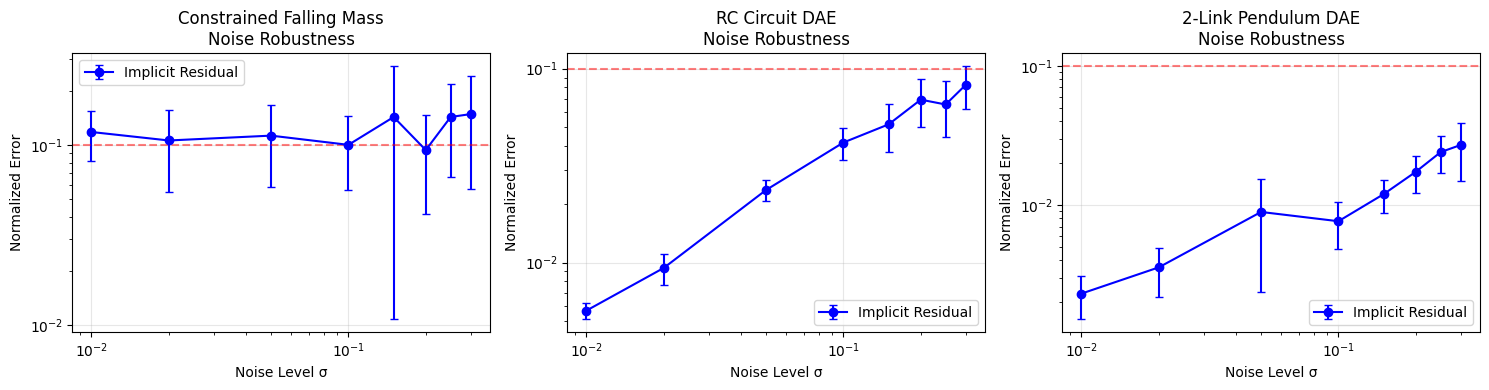

2. Plotting Sparsity vs Noise...


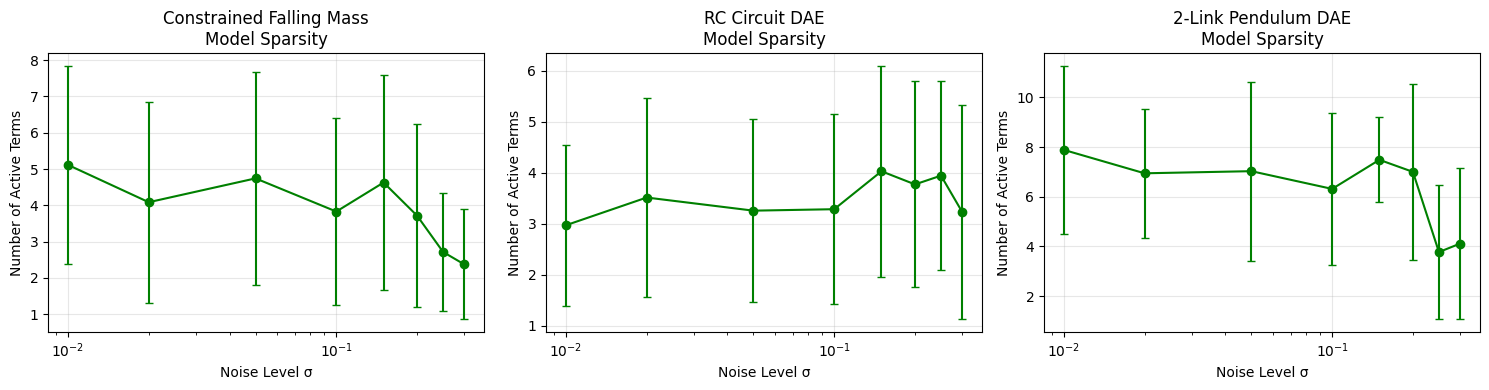

3. Plotting Success Rate Heatmap...


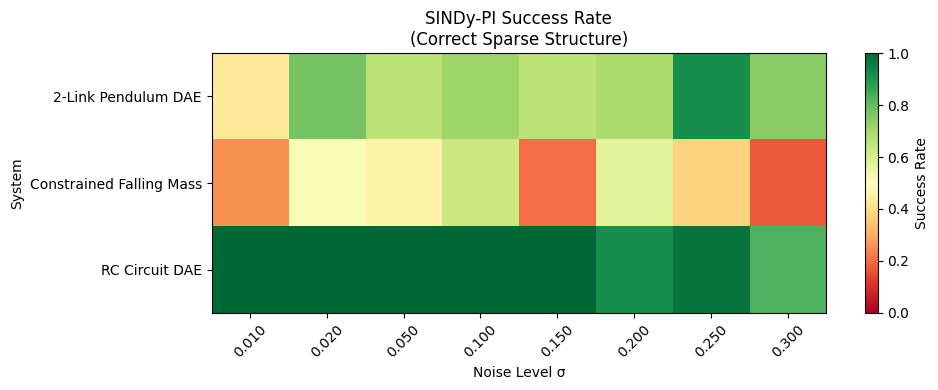

4. Plotting Failure Modes...


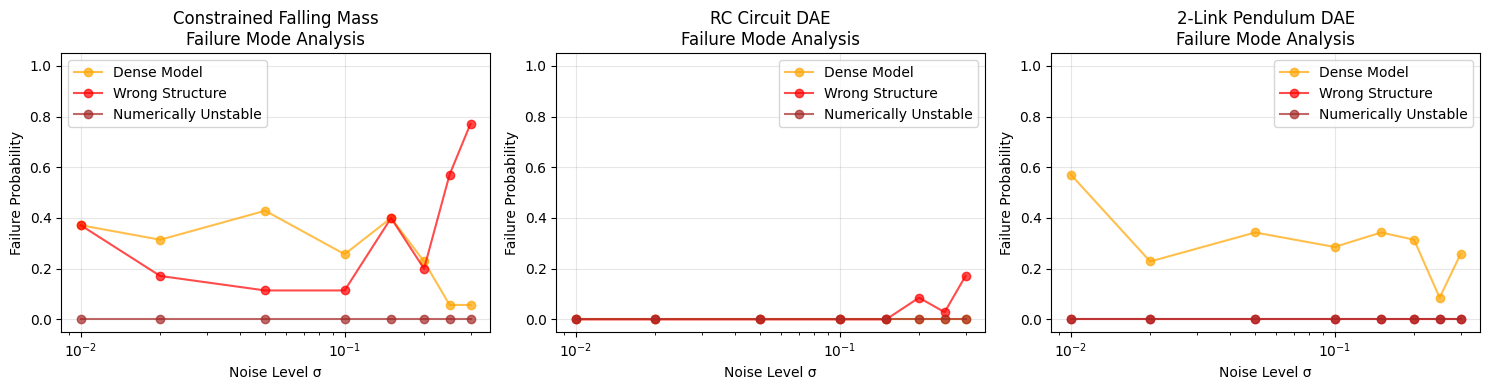

5. Plotting Condition Number Analysis...


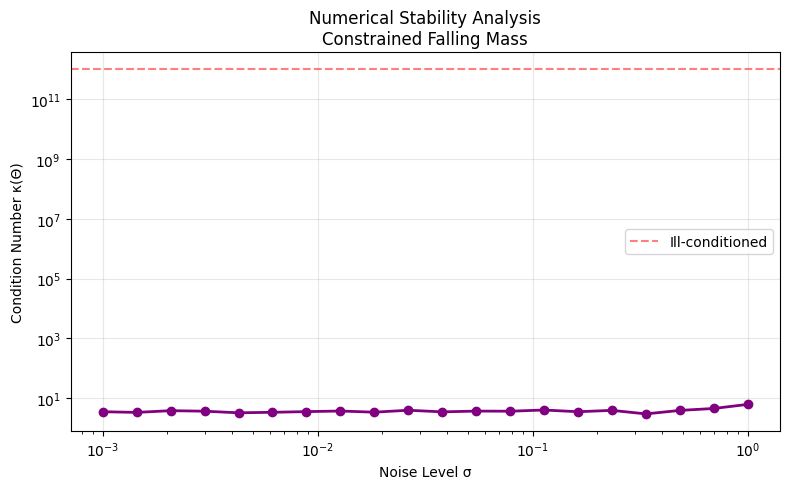

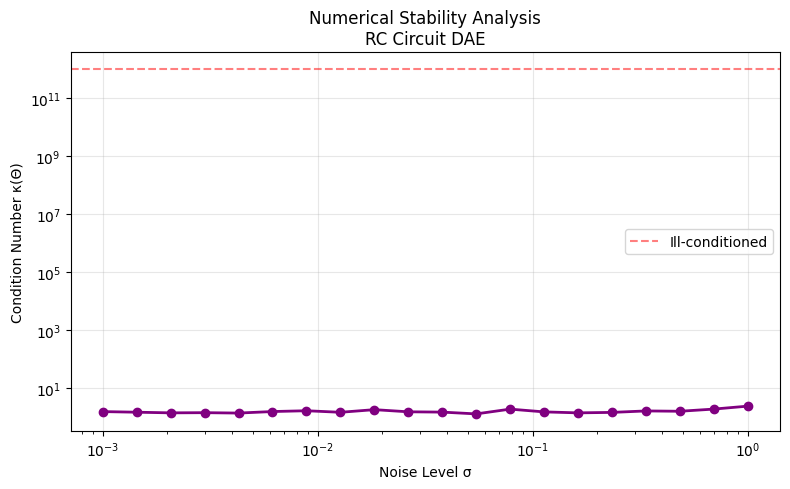

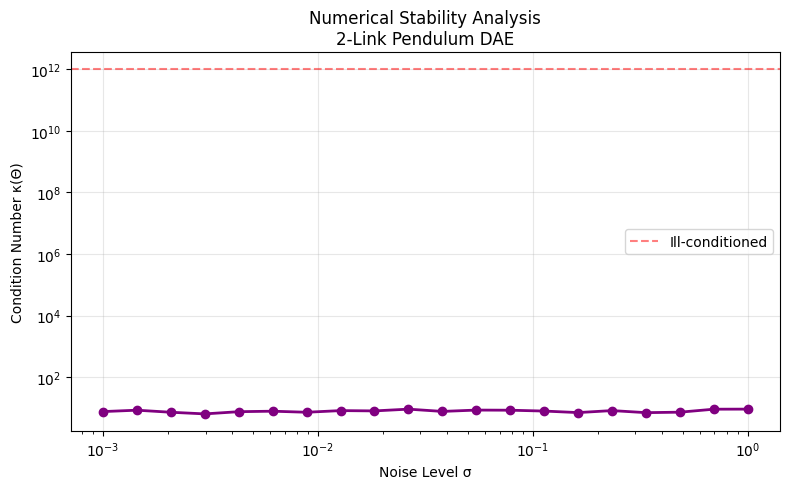


NOISE TOLERANCE SUMMARY
                  System Max Noise (80% success) Noise Tolerance (%)
Constrained Falling Mass                  0.0000                0.0%
          RC Circuit DAE                  0.3000               30.0%
     2-Link Pendulum DAE                  0.0000                0.0%

Experiment Complete!


In [2]:
"""
SINDy-PI Noise Robustness Systematic Study
Based on: Kaheman, K., Kutz, J.N., & Brunton, S.L. (2020)
SINDy-PI: A Robust Algorithm for Parallel Implicit Sparse Identification of Nonlinear Dynamics
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DAE System Definitions
# ============================================================================

@dataclass
class DAESystem:
    """Container for DAE system definition"""
    name: str
    state_names: List[str]
    true_implicit_eqs: List[str]
    params: Dict[str, float]
    n_states: int

    def dynamics(self, t, state):
        """Returns state derivatives"""
        pass

    def implicit_form(self, X, X_dot):
        """Evaluates implicit equation Θ(X, Ẋ)ξ = 0"""
        pass


class ConstrainedFallingMass(DAESystem):
    """
    System 1: Mass falling under gravity with cable constraint

    True implicit form: ẏ² + (ÿ + g)y = 0
    Derived from energy conservation with constraint

    State: [y, ẏ] where y is height, ẏ is velocity
    """

    def __init__(self):
        super().__init__(
            name="Constrained Falling Mass",
            state_names=["y", "y_dot"],
            true_implicit_eqs=["y_dot^2 + (y_ddot + g)*y = 0"],
            params={"g": 9.81, "L": 1.0},
            n_states=2
        )

    def dynamics(self, t, state):
        y, y_dot = state
        g = self.params["g"]
        L = self.params["L"]

        # Constraint: y = L * sin(theta), but here we model directly
        # The constrained dynamics with Lagrangian multiplier
        if abs(y) < 1e-6:
            y = 1e-6

        # Acceleration from constraint
        y_ddot = -(g*y + y_dot**2) / y

        return [y_dot, y_ddot]

    def implicit_form(self, X, X_dot):
        """
        Build library Θ(X, Ẋ) for implicit identification
        Equation: ẏ² + ÿ·y + g·y = 0
        """
        y = X[:, 0:1]
        y_dot = X[:, 1:2]
        y_ddot = X_dot[:, 1:2]

        # Library terms: [1, y, y_dot, y_ddot, y*y_ddot, y_dot^2, y^2, ...]
        Theta = np.hstack([
            np.ones_like(y),           # constant
            y,                          # y
            y_dot,                      # ẏ
            y_ddot,                     # ÿ
            y * y_ddot,                 # y·ÿ
            y_dot**2,                   # ẏ²
            y**2,                       # y²
            y * y_dot,                  # y·ẏ
            y_dot * y_ddot,             # ẏ·ÿ
        ])

        return Theta


class SimpleCircuitDAE(DAESystem):
    """
    System 2: Simple RC circuit with algebraic constraint

    True implicit form for capacitor voltage:
    C·v̇_c + (v_c - V_in)/R = 0

    State: [v_c, i] where v_c is capacitor voltage, i is current
    """

    def __init__(self):
        super().__init__(
            name="RC Circuit DAE",
            state_names=["v_c", "i"],
            true_implicit_eqs=["C*v_c_dot + (v_c - V_in)/R = 0",
                              "i = (V_in - v_c)/R"],
            params={"R": 100.0, "C": 1e-3, "V_in": 5.0},
            n_states=2
        )

    def dynamics(self, t, state):
        v_c, i = state
        R = self.params["R"]
        C = self.params["C"]
        V_in = self.params["V_in"]

        # Algebraic constraint
        i = (V_in - v_c) / R

        # Differential equation
        v_c_dot = i / C

        # For consistency, i_dot from differentiating constraint
        i_dot = -v_c_dot / R

        return [v_c_dot, i_dot]

    def implicit_form(self, X, X_dot):
        """
        Build library for implicit identification
        """
        v_c = X[:, 0:1]
        i = X[:, 1:2]
        v_c_dot = X_dot[:, 0:1]
        i_dot = X_dot[:, 1:2]

        # Library terms
        Theta = np.hstack([
            np.ones_like(v_c),          # constant (V_in/R term)
            v_c,                         # v_c
            i,                           # i
            v_c_dot,                     # v̇_c
            i_dot,                       # i̇
            v_c * i,                     # v_c·i
            v_c * v_c_dot,               # v_c·v̇_c
            i * v_c_dot,                 # i·v̇_c
        ])

        return Theta


class TwoLinkPendulumDAE(DAESystem):
    """
    System 3: 2-Link Pendulum with Constraints (from paper Sec. 4.1)

    State: [φ₁, φ₂, φ̇₁, φ̇₂]
    Implicit form derived from Euler-Lagrange equations
    """

    def __init__(self):
        super().__init__(
            name="2-Link Pendulum DAE",
            state_names=["phi1", "phi2", "phi1_dot", "phi2_dot"],
            true_implicit_eqs=[
                "I1*phi1_ddot + L1^2*m2*phi1_ddot + ... = 0",
                "I2*phi2_ddot + a2^2*m2*phi2_ddot + ... = 0"
            ],
            params={
                "m1": 0.2704, "m2": 0.2056,
                "L1": 0.2667, "L2": 0.2667,
                "a1": 0.191, "a2": 0.1621,
                "I1": 0.003, "I2": 0.0011,
                "g": 9.81
            },
            n_states=4
        )

    def dynamics(self, t, state):
        """From paper Eq. (38) and (39)"""
        phi1, phi2, phi1_dot, phi2_dot = state

        p = self.params
        dphi = phi1 - phi2

        # Mass matrix components
        M11 = p["I1"] + p["I2"] + p["m2"]*p["L1"]**2 + p["m1"]*p["a1"]**2 + p["m2"]*p["a2"]**2
        M12 = p["I2"] + p["m2"]*p["a2"]**2 + p["m2"]*p["L1"]*p["a2"]*np.cos(dphi)
        M21 = M12
        M22 = p["I2"] + p["m2"]*p["a2"]**2

        # Coriolis and gravity terms
        C1 = -p["m2"]*p["L1"]*p["a2"]*np.sin(dphi)*phi2_dot**2
        C2 = p["m2"]*p["L1"]*p["a2"]*np.sin(dphi)*phi1_dot**2

        G1 = -(p["m1"]*p["a1"] + p["m2"]*p["L1"])*p["g"]*np.sin(phi1) - p["m2"]*p["a2"]*p["g"]*np.sin(phi2)
        G2 = -p["m2"]*p["a2"]*p["g"]*np.sin(phi2)

        # Solve for accelerations
        det = M11*M22 - M12*M21
        if abs(det) < 1e-10:
            det = 1e-10
        phi1_ddot = (M22*(C1 + G1) - M12*(C2 + G2)) / det
        phi2_ddot = (-M21*(C1 + G1) + M11*(C2 + G2)) / det

        return [phi1_dot, phi2_dot, phi1_ddot, phi2_ddot]

    def implicit_form(self, X, X_dot):
        """
        Build library for implicit identification of double pendulum
        Based on paper Sec. 4.1
        """
        phi1 = X[:, 0:1]
        phi2 = X[:, 1:2]
        phi1_dot = X[:, 2:3]
        phi2_dot = X[:, 3:4]
        phi1_ddot = X_dot[:, 2:3]
        phi2_ddot = X_dot[:, 3:4]

        # Trigonometric terms (as in paper)
        sin_phi1 = np.sin(phi1)
        cos_phi1 = np.cos(phi1)
        sin_phi2 = np.sin(phi2)
        cos_phi2 = np.cos(phi2)
        sin_dphi = np.sin(phi1 - phi2)
        cos_dphi = np.cos(phi1 - phi2)
        sin_2dphi = np.sin(2*(phi1 - phi2))
        cos_2dphi = np.cos(2*(phi1 - phi2))

        # Build library following paper's approach
        Theta = np.hstack([
            phi1_ddot,                   # φ̈₁
            phi2_ddot,                   # φ̈₂
            phi1_dot**2,                 # φ̇₁²
            phi2_dot**2,                 # φ̇₂²
            phi1_dot * phi2_dot,         # φ̇₁φ̇₂
            sin_phi1,                    # sin(φ₁)
            sin_phi2,                    # sin(φ₂)
            cos_phi1,                    # cos(φ₁)
            cos_phi2,                    # cos(φ₂)
            phi1_ddot * cos_dphi,        # φ̈₁cos(φ₁-φ₂)
            phi2_ddot * cos_dphi,        # φ̈₂cos(φ₁-φ₂)
            phi1_dot**2 * sin_dphi,      # φ̇₁²sin(φ₁-φ₂)
            phi2_dot**2 * sin_dphi,      # φ̇₂²sin(φ₁-φ₂)
            phi1_dot**2 * sin_2dphi,     # φ̇₁²sin(2(φ₁-φ₂))
            phi2_dot**2 * sin_2dphi,     # φ̇₂²sin(2(φ₁-φ₂))
            np.ones_like(phi1),          # constant
        ])

        return Theta


# ============================================================================
# PART 2: SINDy-PI Implementation (from paper Algorithm)
# ============================================================================

class SINDyPI:
    """
    SINDy-PI: Parallel Implicit Sparse Identification of Nonlinear Dynamics

    Based on Algorithm from Kaheman et al., 2020
    Key insight: Test each candidate function θⱼ as LHS, solve for sparse RHS
    """

    def __init__(self, lambda_threshold: float = 0.1,
                 max_iterations: int = 20):
        """
        Args:
            lambda_threshold: Sparsity threshold for STLSQ
            max_iterations: Maximum iterations for thresholding
        """
        self.lambda_threshold = lambda_threshold
        self.max_iterations = max_iterations
        self.candidate_models = {}

    def fit(self, Theta: np.ndarray,
            candidate_indices: Optional[List[int]] = None) -> Dict:
        """
        Fit SINDy-PI model following paper Eq. (10):
        θⱼ(X, Ẋ) = Θ(X, Ẋ | θⱼ) ξⱼ

        Args:
            Theta: Library matrix Θ(X, Ẋ)
            candidate_indices: Indices of terms to test as LHS

        Returns:
            Dictionary of identified models
        """
        n_terms = Theta.shape[1]

        if candidate_indices is None:
            candidate_indices = list(range(n_terms))

        models = {}

        for j in candidate_indices:
            # Extract candidate term (LHS)
            lhs = Theta[:, j:j+1]

            # Build RHS library (exclude candidate term)
            rhs_library = np.delete(Theta, j, axis=1)

            # Solve sparse regression: min ||lhs - rhs_library·ξ||₂ + β||ξ||₀
            xi = self._sparse_regression(lhs, rhs_library)

            # Store model
            models[j] = {
                'lhs_index': j,
                'coefficients': xi,
                'sparsity': np.sum(np.abs(xi) > 1e-6),
                'residual': np.linalg.norm(lhs - rhs_library @ xi) / (np.linalg.norm(lhs) + 1e-10)
            }

        self.candidate_models = models
        return models

    def _sparse_regression(self, lhs: np.ndarray,
                          rhs_library: np.ndarray) -> np.ndarray:
        """
        Sequentially Thresholded Least Squares (STLSQ)
        From Brunton et al., 2016
        """
        # Initial least squares solution
        try:
            xi = lstsq(rhs_library, lhs)[0].flatten()
        except:
            xi = np.zeros(rhs_library.shape[1])

        for iteration in range(self.max_iterations):
            # Threshold small coefficients
            small_indices = np.abs(xi) < self.lambda_threshold
            xi[small_indices] = 0

            # Refit non-zero coefficients
            if np.sum(~small_indices) > 0:
                active_cols = np.where(~small_indices)[0]
                try:
                    xi_active = lstsq(rhs_library[:, active_cols], lhs)[0].flatten()
                    xi[active_cols] = xi_active
                except:
                    pass

        return xi

    def select_best_model(self, Theta_val: np.ndarray) -> Tuple[int, np.ndarray]:
        """
        Model selection based on validation data
        Paper Eq. (12): Error = ||θⱼ - Θ|θⱼ·Ξ||₂ / ||θⱼ||₂
        """
        best_score = np.inf
        best_model_idx = None
        best_coefficients = None

        for j, model in self.candidate_models.items():
            lhs_val = Theta_val[:, j:j+1]
            rhs_val = np.delete(Theta_val, j, axis=1)

            pred = rhs_val @ model['coefficients'].reshape(-1, 1)
            error = np.linalg.norm(lhs_val - pred) / (np.linalg.norm(lhs_val) + 1e-10)

            if error < best_score:
                best_score = error
                best_model_idx = j
                best_coefficients = model['coefficients']

        return best_model_idx, best_coefficients


# ============================================================================
# PART 3: Noise Robustness Evaluation
# ============================================================================

class NoiseRobustnessExperiment:
    """
    Systematic noise robustness evaluation for SINDy-PI
    """

    def __init__(self, system: DAESystem,
                 noise_levels: Optional[List[float]] = None):
        """
        Args:
            system: DAE system to test
            noise_levels: List of noise magnitudes (σ)
        """
        self.system = system

        if noise_levels is None:
            # From paper: test from 1e-7 to 0.5 (50%)
            self.noise_levels = np.logspace(-3, -0.3, 15)  # 0.1% to 50%
        else:
            self.noise_levels = noise_levels

        self.results = []

    def run(self, n_trials: int = 10) -> pd.DataFrame:
        """
        Run noise robustness experiment

        Args:
            n_trials: Number of noise realizations per noise level
        """
        results = []

        for sigma in self.noise_levels:
            print(f"  Testing noise level σ = {sigma:.4f}")

            for trial in range(n_trials):
                # Generate data with noise
                X_train, X_dot_train = self._generate_training_data(sigma)
                X_val, X_dot_val = self._generate_validation_data(sigma)

                # Build library
                Theta_train = self.system.implicit_form(X_train, X_dot_train)
                Theta_val = self.system.implicit_form(X_val, X_dot_val)

                # Fit SINDy-PI with various thresholds
                best_models = self._sweep_thresholds(Theta_train, Theta_val)

                # Evaluate
                for lambda_thresh, model_info in best_models.items():
                    metrics = self._evaluate_model(
                        model_info, X_val, X_dot_val, Theta_val, sigma
                    )
                    metrics.update({
                        'noise_level': sigma,
                        'trial': trial,
                        'lambda_threshold': lambda_thresh
                    })
                    results.append(metrics)

        self.results = pd.DataFrame(results)
        return self.results

    def _generate_training_data(self, sigma: float) -> Tuple[np.ndarray, np.ndarray]:
        """Generate training data with noise"""
        n_ics = 10  # Reduced for faster execution
        t_span = (0, 3)
        t_eval = np.linspace(0, 3, 200)

        X_list = []
        X_dot_list = []

        for _ in range(n_ics):
            # Random initial condition
            x0 = self._random_initial_condition()

            # Simulate
            sol = solve_ivp(
                self.system.dynamics, t_span, x0,
                t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8
            )

            X_clean = sol.y.T
            X_dot_clean = np.array([self.system.dynamics(t, x) for t, x in zip(sol.t, X_clean)])

            # Add Gaussian noise
            if sigma > 0:
                std_X = np.std(X_clean, axis=0)
                std_X[std_X < 1e-6] = 1.0
                noise = np.random.randn(*X_clean.shape) * sigma * std_X
                X_noisy = X_clean + noise
            else:
                X_noisy = X_clean

            # Compute derivatives from noisy data
            X_dot_noisy = self._compute_derivative(X_noisy, sol.t)

            X_list.append(X_noisy)
            X_dot_list.append(X_dot_noisy)

        return np.vstack(X_list), np.vstack(X_dot_list)

    def _generate_validation_data(self, sigma: float) -> Tuple[np.ndarray, np.ndarray]:
        """Generate validation data"""
        n_ics = 3  # 20% of training size
        t_span = (0, 3)
        t_eval = np.linspace(0, 3, 200)

        X_list = []
        X_dot_list = []

        for _ in range(n_ics):
            x0 = self._random_initial_condition()
            sol = solve_ivp(
                self.system.dynamics, t_span, x0,
                t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8
            )

            X_clean = sol.y.T
            if sigma > 0:
                std_X = np.std(X_clean, axis=0)
                std_X[std_X < 1e-6] = 1.0
                noise = np.random.randn(*X_clean.shape) * sigma * std_X
                X_noisy = X_clean + noise
            else:
                X_noisy = X_clean
            X_dot_noisy = self._compute_derivative(X_noisy, sol.t)

            X_list.append(X_noisy)
            X_dot_list.append(X_dot_noisy)

        return np.vstack(X_list), np.vstack(X_dot_list)

    def _random_initial_condition(self) -> np.ndarray:
        """Generate random initial condition"""
        n = self.system.n_states
        if n == 2:
            return np.array([np.random.uniform(0.5, 2.0),
                            np.random.uniform(-0.5, 0.5)])
        elif n == 4:
            return np.array([np.random.uniform(-0.5, 0.5),
                            np.random.uniform(-0.5, 0.5),
                            np.random.uniform(-1.0, 1.0),
                            np.random.uniform(-1.0, 1.0)])
        else:
            return np.random.uniform(-1.0, 1.0, n)

    def _compute_derivative(self, X: np.ndarray, t: np.ndarray) -> np.ndarray:
        """Compute derivative using finite difference"""
        X_dot = np.zeros_like(X)
        dt = t[1] - t[0]

        # Central difference for interior points
        X_dot[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
        # Forward/backward for boundaries
        X_dot[0] = (X[1] - X[0]) / dt
        X_dot[-1] = (X[-1] - X[-2]) / dt

        return X_dot

    def _sweep_thresholds(self, Theta_train: np.ndarray,
                          Theta_val: np.ndarray) -> Dict:
        """Sweep through sparsity thresholds"""
        lambda_values = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
        best_models = {}

        for lambda_thresh in lambda_values:
            model = SINDyPI(lambda_threshold=lambda_thresh)
            model.fit(Theta_train)

            # Select best model on validation data
            best_idx, coefficients = model.select_best_model(Theta_val)

            best_models[lambda_thresh] = {
                'model': model,
                'best_idx': best_idx,
                'coefficients': coefficients,
                'sparsity': np.sum(np.abs(coefficients) > 1e-6)
            }

        return best_models

    def _evaluate_model(self, model_info: Dict,
                        X_val: np.ndarray,
                        X_dot_val: np.ndarray,
                        Theta_val: np.ndarray,
                        sigma: float) -> Dict:
        """
        Evaluate model using paper's metrics
        """
        best_idx = model_info['best_idx']
        coefficients = model_info['coefficients']

        # 1. Implicit residual RMSE
        lhs_val = Theta_val[:, best_idx:best_idx+1]
        rhs_val = np.delete(Theta_val, best_idx, axis=1)
        pred = rhs_val @ coefficients.reshape(-1, 1)
        implicit_residual = np.linalg.norm(lhs_val - pred) / (np.linalg.norm(lhs_val) + 1e-10)

        # 2. Determine success (sparse model with low residual)
        sparsity = model_info['sparsity']
        success = (sparsity > 0 and sparsity < 8 and implicit_residual < 0.1)

        # 3. Failure modes
        is_dense = sparsity > 7
        is_wrong_structure = (not success) and (not is_dense)
        is_unstable = implicit_residual > 1.0

        return {
            'implicit_residual': implicit_residual,
            'sparsity': sparsity,
            'success': int(success),
            'dense': int(is_dense),
            'wrong_structure': int(is_wrong_structure),
            'unstable': int(is_unstable)
        }


# ============================================================================
# PART 4: Visualization and Analysis
# ============================================================================

class NoiseRobustnessVisualizer:
    """
    Visualization tools for noise robustness analysis
    """

    @staticmethod
    def plot_residual_vs_noise(results_df: pd.DataFrame,
                               save_path: Optional[str] = None):
        """
        Figure: Implicit residual RMSE vs noise level
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        systems = results_df['system'].unique()

        for idx, system in enumerate(systems):
            ax = axes[idx]
            system_df = results_df[results_df['system'] == system]

            # Group by noise level
            grouped = system_df.groupby('noise_level').agg({
                'implicit_residual': ['mean', 'std']
            }).reset_index()

            noise = grouped['noise_level']

            # Plot implicit residual
            ax.errorbar(noise, grouped['implicit_residual']['mean'],
                       yerr=grouped['implicit_residual']['std'],
                       fmt='o-', capsize=3, color='blue', label='Implicit Residual')

            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel('Noise Level σ')
            ax.set_ylabel('Normalized Error')
            ax.set_title(f'{system}\nNoise Robustness')
            ax.legend()
            ax.grid(True, alpha=0.3)

            # Mark failure threshold
            ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Failure Threshold')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_sparsity_vs_noise(results_df: pd.DataFrame,
                               save_path: Optional[str] = None):
        """
        Figure: Coefficient sparsity vs noise level
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        systems = results_df['system'].unique()

        for idx, system in enumerate(systems):
            ax = axes[idx]
            system_df = results_df[results_df['system'] == system]

            grouped = system_df.groupby('noise_level').agg({
                'sparsity': ['mean', 'std']
            }).reset_index()

            noise = grouped['noise_level']
            sparsity = grouped['sparsity']['mean']
            sparsity_std = grouped['sparsity']['std']

            ax.errorbar(noise, sparsity, yerr=sparsity_std,
                       fmt='o-', capsize=3, color='green')

            ax.set_xscale('log')
            ax.set_xlabel('Noise Level σ')
            ax.set_ylabel('Number of Active Terms')
            ax.set_title(f'{system}\nModel Sparsity')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_condition_number_analysis(system: DAESystem,
                                       save_path: Optional[str] = None):
        """
        Figure: Condition number of Θ matrix vs noise level
        """
        fig, ax = plt.subplots(figsize=(8, 5))

        noise_levels = np.logspace(-3, 0, 20)
        condition_numbers = []

        for sigma in noise_levels:
            # Generate sample data
            n_samples = 200
            X = np.random.randn(n_samples, system.n_states)
            X_dot = np.random.randn(n_samples, system.n_states)

            # Add noise
            if sigma > 0:
                std_X = np.std(X, axis=0)
                std_X[std_X < 1e-6] = 1.0
                noise = np.random.randn(*X.shape) * sigma * std_X
                X_noisy = X + noise
            else:
                X_noisy = X

            Theta = system.implicit_form(X_noisy, X_dot)

            # Compute condition number
            try:
                cond_num = np.linalg.cond(Theta)
                condition_numbers.append(cond_num)
            except:
                condition_numbers.append(np.inf)

        ax.semilogy(noise_levels, condition_numbers, 'o-', linewidth=2, color='purple')
        ax.set_xscale('log')
        ax.set_xlabel('Noise Level σ')
        ax.set_ylabel('Condition Number κ(Θ)')
        ax.set_title(f'Numerical Stability Analysis\n{system.name}')
        ax.grid(True, alpha=0.3)

        # Mark ill-conditioning threshold
        ax.axhline(y=1e12, color='red', linestyle='--',
                  alpha=0.5, label='Ill-conditioned')
        ax.legend()

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_success_rate_heatmap(results_df: pd.DataFrame,
                                  save_path: Optional[str] = None):
        """
        Figure: Success rate heatmap across systems and noise levels
        """
        fig, ax = plt.subplots(figsize=(10, 4))

        # Pivot table
        pivot = results_df.pivot_table(
            values='success',
            index='noise_level',
            columns='system',
            aggfunc='mean'
        )

        im = ax.imshow(pivot.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

        # Labels
        ax.set_xticks(range(len(pivot.index)))
        ax.set_xticklabels([f'{x:.3f}' for x in pivot.index], rotation=45)
        ax.set_yticks(range(len(pivot.columns)))
        ax.set_yticklabels(pivot.columns)

        ax.set_xlabel('Noise Level σ')
        ax.set_ylabel('System')
        ax.set_title('SINDy-PI Success Rate\n(Correct Sparse Structure)')

        # Colorbar
        plt.colorbar(im, ax=ax, label='Success Rate')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_failure_modes(results_df: pd.DataFrame,
                          save_path: Optional[str] = None):
        """
        Figure: Failure mode analysis
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        systems = results_df['system'].unique()
        failure_modes = ['dense', 'wrong_structure', 'unstable']
        colors = ['orange', 'red', 'brown']
        labels = ['Dense Model', 'Wrong Structure', 'Numerically Unstable']

        for idx, system in enumerate(systems):
            ax = axes[idx]
            system_df = results_df[results_df['system'] == system]

            for mode, color, label in zip(failure_modes, colors, labels):
                grouped = system_df.groupby('noise_level')[mode].mean()
                ax.plot(grouped.index, grouped.values, 'o-',
                       color=color, label=label, alpha=0.7)

            ax.set_xscale('log')
            ax.set_xlabel('Noise Level σ')
            ax.set_ylabel('Failure Probability')
            ax.set_title(f'{system}\nFailure Mode Analysis')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def print_summary_table(results_df: pd.DataFrame):
        """
        Print summary table of noise tolerance
        """
        print("\n" + "="*70)
        print("NOISE TOLERANCE SUMMARY")
        print("="*70)

        systems = results_df['system'].unique()

        summary_data = []
        for system in systems:
            system_df = results_df[results_df['system'] == system]

            # Find maximum noise level with >80% success rate
            grouped = system_df.groupby('noise_level')['success'].mean().reset_index()
            grouped = grouped.sort_values('noise_level')

            max_noise = 0.0
            for _, row in grouped.iterrows():
                if row['success'] >= 0.8:
                    max_noise = row['noise_level']
                else:
                    break

            summary_data.append({
                'System': system,
                'Max Noise (80% success)': f"{max_noise:.4f}",
                'Noise Tolerance (%)': f"{max_noise*100:.1f}%"
            })

        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        print("="*70)

        return summary_df


# ============================================================================
# PART 5: Main Execution
# ============================================================================

def main():
    """
    Run complete SINDy-PI noise robustness study
    """
    print("=" * 70)
    print("SINDy-PI Noise Robustness Systematic Study")
    print("Based on Kaheman et al., 2020")
    print("=" * 70)

    # Define systems to test
    systems = [
        ConstrainedFallingMass(),
        SimpleCircuitDAE(),
        TwoLinkPendulumDAE()
    ]

    # Noise levels from paper: 1% to 30%
    noise_levels = np.array([0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3])

    all_results = []

    for system in systems:
        print(f"\n{'='*50}")
        print(f"Testing System: {system.name}")
        print(f"{'='*50}")

        # Run experiment
        experiment = NoiseRobustnessExperiment(system, noise_levels)
        results = experiment.run(n_trials=5)
        results['system'] = system.name
        all_results.append(results)

    # Combine all results
    combined_results = pd.concat(all_results, ignore_index=True)

    # Visualize
    print("\n" + "="*50)
    print("Generating Visualizations...")
    print("="*50)

    viz = NoiseRobustnessVisualizer()

    # Figure 1: Residual vs Noise
    print("\n1. Plotting Residual vs Noise...")
    viz.plot_residual_vs_noise(combined_results,
                               save_path='fig1_residual_vs_noise.png')

    # Figure 2: Sparsity vs Noise
    print("2. Plotting Sparsity vs Noise...")
    viz.plot_sparsity_vs_noise(combined_results,
                               save_path='fig2_sparsity_vs_noise.png')

    # Figure 3: Success Rate Heatmap
    print("3. Plotting Success Rate Heatmap...")
    viz.plot_success_rate_heatmap(combined_results,
                                  save_path='fig3_success_rate_heatmap.png')

    # Figure 4: Failure Modes
    print("4. Plotting Failure Modes...")
    viz.plot_failure_modes(combined_results,
                          save_path='fig4_failure_modes.png')

    # Figure 5: Condition Number Analysis (for each system)
    print("5. Plotting Condition Number Analysis...")
    for i, system in enumerate(systems):
        viz.plot_condition_number_analysis(
            system,
            save_path=f'fig5_condition_number_{i+1}.png'
        )

    # Print summary
    viz.print_summary_table(combined_results)

    print("\n" + "="*70)
    print("Experiment Complete!")
    print("="*70)

    return combined_results


# ============================================================================
# Run if executed as script
# ============================================================================

if __name__ == "__main__":
    results = main()